# Classifiez automatiquement des biens de consommation

In [2]:
from IPython.display import display, HTML
display(HTML("<div style='text-align: center;'><img src='logo.png' alt='Logo' width='400'></div>"))

In [3]:
!pip install plot_keras_history

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import seaborn as sns
import fonctions as fc
import importlib
import time

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn import cluster, metrics

import os
from os import listdir
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, adjusted_rand_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalAveragePooling1D, Flatten, Dense, Dropout 
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from PIL import Image
Image.MAX_IMAGE_PIXELS = None

import cv2
from PIL import Image, ImageOps, ImageFilter
from IPython.display import Image, display

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [5]:
importlib.reload(fc)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


<module 'fonctions' from 'C:\\Users\\steph\\Documents\\OPENCLASSROOMS\\Projets\\Projet6_Classifiez_automatiquement_des_biens_de_consommation\\fonctions.py'>

## Enoncé
Vous êtes Data Scientist au sein de l’entreprise **"Place de marché”**, qui souhaite lancer une marketplace e-commerce.

Sur cette place de marché anglophone, des vendeurs proposent des articles à des acheteurs en postant une photo et une description.

Pour l'instant, l'attribution de la catégorie d'un article est effectuée manuellement par les vendeurs, et est donc peu fiable. De plus, le volume des articles est pour l’instant très petit.

Pour rendre l’expérience utilisateur des vendeurs (faciliter la mise en ligne de nouveaux articles) et des acheteurs (faciliter la recherche de produits) la plus fluide possible, et dans l'optique d'un passage à l'échelle, il devient nécessaire d'automatiser cette tâche d‘attribution de la categorie.

Linda, Lead Data Scientist, vous demande donc d'étudier la faisabilité d'un moteur de classification des articles en différentes catégories, à partir du texte (en anglais) et de l’image comme dans l’illustration ci-dessous.

## Missions
La faisabilité de regrouper automatiquement des produits de même catégorie a pu être démontré dans les deux notebooks précédents.

Dans ce notebook, nous nous concentrerons sur la réalisation d'une classification supervisée à partir d'images:

**"Je souhaiterais que tu mettes en place une data augmentation afin d’optimiser le modèle".**


## I- Visualisation des données

In [6]:
# Import du jeu de données
df = pd.read_csv("C:\\Users\\steph\\Documents\\OPENCLASSROOMS\\Projets\\Projet6_Classifiez_automatiquement_des_biens_de_consommation\\path_image_cleaned.csv")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
df.head()

,image,main_category,path_image,processed_images
0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,home furnishing,Images/55b85ea15a1536d46b7190ad6fff8ce7.jpg,Images_processed\55b85ea15a1536d46b7190ad6fff8...
1,7b72c92c2f6c40268628ec5f14c6d590.jpg,baby care,Images/7b72c92c2f6c40268628ec5f14c6d590.jpg,Images_processed\7b72c92c2f6c40268628ec5f14c6d...
2,64d5d4a258243731dc7bbb1eef49ad74.jpg,baby care,Images/64d5d4a258243731dc7bbb1eef49ad74.jpg,Images_processed\64d5d4a258243731dc7bbb1eef49a...
3,d4684dcdc759dd9cdf41504698d737d8.jpg,home furnishing,Images/d4684dcdc759dd9cdf41504698d737d8.jpg,Images_processed\d4684dcdc759dd9cdf41504698d73...
4,6325b6870c54cd47be6ebfbffa620ec7.jpg,home furnishing,Images/6325b6870c54cd47be6ebfbffa620ec7.jpg,Images_processed\6325b6870c54cd47be6ebfbffa620...


In [7]:
print('Ce jeu de donnée comporte ' + str(df.shape[0]) + ' lignes et ' + str(df.shape[1]) + ' colonnes')

Ce jeu de donnée comporte 1050 lignes et 4 colonnes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   image             1050 non-null   object
 1   main_category     1050 non-null   object
 2   path_image        1050 non-null   object
 3   processed_images  1050 non-null   object
dtypes: object(4)
memory usage: 32.9+ KB


## II- Nettoyage des données
- On élimine les colonnes inutiles pour ce notebook

In [9]:
# Elimination des variables inutiles pour ce notebook
df = df.drop(["image", "processed_images"], axis= 1)
df.head()

,main_category,path_image
0,home furnishing,Images/55b85ea15a1536d46b7190ad6fff8ce7.jpg
1,baby care,Images/7b72c92c2f6c40268628ec5f14c6d590.jpg
2,baby care,Images/64d5d4a258243731dc7bbb1eef49ad74.jpg
3,home furnishing,Images/d4684dcdc759dd9cdf41504698d737d8.jpg
4,home furnishing,Images/6325b6870c54cd47be6ebfbffa620ec7.jpg


- La variable **'main_category'** doit être encodé

In [10]:
# Encodage de la catégorie
encoder= LabelEncoder()
df["class"] = encoder.fit_transform(df["main_category"])
df.head()

,main_category,path_image,class
0,home furnishing,Images/55b85ea15a1536d46b7190ad6fff8ce7.jpg,4
1,baby care,Images/7b72c92c2f6c40268628ec5f14c6d590.jpg,0
2,baby care,Images/64d5d4a258243731dc7bbb1eef49ad74.jpg,0
3,home furnishing,Images/d4684dcdc759dd9cdf41504698d737d8.jpg,4
4,home furnishing,Images/6325b6870c54cd47be6ebfbffa620ec7.jpg,4


In [11]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, random_state=42)

data_ = np.concatenate((X_train, y_train.to_numpy().reshape(-1, 1)), axis=1)
data = pd.DataFrame(data_, columns=list(X.columns) + ['label'])
data_test_ = np.concatenate((X_test, y_test.to_numpy().reshape(-1, 1)), axis=1)
data_test = pd.DataFrame(data_test_, columns=list(X.columns) + ['label'])

In [12]:
print(data.shape)
data.head(2)

(900, 3)


,main_category,path_image,label
0,watches,Images/c7207128c680a437e1cad834a8880007.jpg,6
1,beauty and personal care,Images/417ae3e8b08acc19a023b8a958644799.jpg,1


In [13]:
print(data_test.shape)
data_test.head(2)

(150, 3)


,main_category,path_image,label
0,computers,Images/833a87b0af3b84fe246d2ebf271af177.jpg,2
1,kitchen and dining,Images/55195de3873fffaa9e37b041533d7305.jpg,5


## III- Classification supervisée

### 3.1) Création du modèle de classification

La fonction **create_model_fct()** retourne un modèle **CNN** pré-entraîné basé sur l'architecture **VGG16** avec un nouveau classifieur ajouté. Le modèle est chargé avec les poids entraînés sur l'ensemble de données **ImageNet**. Seuls les derniers couches du modèle sont entraînables et les poids des couches de convolution sont figés. Le modèle est compilé avec une fonction de perte **categorical_crossentropy;** et **l'optimiseur rmsprop**. 

Enfin, la fonction retourne le modèle.

In [14]:
def create_model_fct() :
    # Récupération modèle pré-entraîné
    model0 = VGG16(include_top=False, weights="imagenet", input_shape=(224, 224, 3))

    # Layer non entraînables = on garde les poids du modèle pré-entraîné
    for layer in model0.layers:
        layer.trainable = False

    # Récupérer la sortie de ce réseau
    x = model0.output
    # Compléter le modèle
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(7, activation='softmax')(x)

    # Définir le nouveau modèle
    model = Model(inputs=model0.input, outputs=predictions)
    # compilation du modèle 
    model.compile(loss="categorical_crossentropy", optimizer='rmsprop', metrics=["accuracy"])

    print(model.summary())
    
    return model

### 3.2) Approche préparation initiale des images

In [15]:
def image_prep_fct(data) :
    prepared_images = []
    for image_num in range(len(data['path_image'])) :
        img = (load_img(data['path_image'][image_num], target_size=(224, 224)))
        img = img_to_array(img)
        img = img.reshape((img.shape[0], img.shape[1], img.shape[2]))
        img = preprocess_input(img)
        prepared_images.append(img)
    prepared_images_np = np.array(prepared_images)
    return prepared_images_np
    
images_np = image_prep_fct(data)
print(images_np.shape)
images_np_test = image_prep_fct(data_test)
print(images_np_test.shape)

(900, 224, 224, 3)
(150, 224, 224, 3)


### 3.3) Séparation du jeu de données

- Utiliser la stratification lors de la séparation garantit que la distribution des catégories est maintenue uniformément dans tous les sous-ensembles

In [16]:
X = images_np
y = to_categorical(data['label'])

X_test = images_np_test
y_test = to_categorical(data_test['label'])

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)
X_train.shape

(675, 224, 224, 3)

### 3.4) Création du modèle

In [19]:
# Création du modèle
# with tf.device('/cpu:0'): 
model1 = create_model_fct()

# Création du callback
model1_save_path1 = "./model1_best_weights.h5"
#checkpoint = ModelCheckpoint(model1_save_path1, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
checkpoint = ModelCheckpoint(model1_save_path1, monitor='val_loss', verbose=1, save_best_only=True, mode='min', save_weights_only=False)
#es = EarlyStopping(monitor='val_accuracy', mode='max', verbose=1, patience=5)
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
callbacks_list = [checkpoint, es]

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

- **`Layer (Type)`** : montre le **nom** et le **type** de chaque couche du modèle.  
  Par exemple, `'input_1'` est une **couche d'entrée**, alors que `'block1_conv1'` est une **couche de convolution** (`Conv2D`).

- **`Output Shape`** : indique la **forme de la sortie** de chaque couche.  
  Exemple : `(None, 224, 224, 64)` signifie que la sortie est un tenseur de forme  
  `(batch_size, hauteur, largeur, canaux)`.  
  Ici :
  - `None` représente la **taille du batch** (non fixée à ce stade),
  - `224 x 224` sont les dimensions spatiales de l’image,
  - `64` est le **nombre de filtres** (canaux) en sortie de la couche.

- **`Param #`** : correspond au **nombre de paramètres** de chaque couche.  
  Par exemple, pour une couche `Conv2D`, il s’agit des poids + biais à apprendre.

- **`Total params`** : total de **tous les paramètres** du modèle (entraînables + non entraînables).

- **`Trainable params`** : paramètres **entraînables** pendant l’apprentissage (par exemple, ceux des couches `Dense` ajoutées à la fin du modèle).

- **`Non-trainable params`** : paramètres **gelés**, souvent issus d’un modèle pré-entraîné (comme les poids des couches convolutives de VGG16 dans notre cas).

In [21]:
# Entraîner sur les données d'entraînement approche simple (X_train, y_train)
with tf.device('/cpu:0'): 
    history1 = model1.fit(X_train, y_train, epochs=50, batch_size=64, 
                       callbacks=callbacks_list, validation_data=(X_val, y_val), verbose=1)

Epoch 1/50
11/11 [==============================] - ETA: 0s - loss: 5.8380 - accuracy: 0.4430 
Epoch 1: val_loss improved from inf to 1.25555, saving model to .\model1_best_weights.h5
11/11 [==============================] - 167s 15s/step - loss: 5.8380 - accuracy: 0.4430 - val_loss: 1.2555 - val_accuracy: 0.7378
Epoch 2/50
11/11 [==============================] - ETA: 0s - loss: 1.7894 - accuracy: 0.6933 
Epoch 2: val_loss improved from 1.25555 to 1.07006, saving model to .\model1_best_weights.h5
11/11 [==============================] - 179s 17s/step - loss: 1.7894 - accuracy: 0.6933 - val_loss: 1.0701 - val_accuracy: 0.7644
Epoch 3/50
11/11 [==============================] - ETA: 0s - loss: 1.0940 - accuracy: 0.7733 
Epoch 3: val_loss improved from 1.07006 to 1.06044, saving model to .\model1_best_weights.h5
11/11 [==============================] - 165s 15s/step - loss: 1.0940 - accuracy: 0.7733 - val_loss: 1.0604 - val_accuracy: 0.7778
Epoch 4/50
11/11 [=============================

### Évaluation du modèle

**Training Accuracy :**  
La précision sur l'ensemble d'entraînement s'est progressivement améliorée au fil des époques, passant de **44,30 %** à **95,56 %**. Cela montre que le modèle a appris efficacement à classer les données d'entraînement, atteignant une excellente performance sur cet ensemble.

**Validation Accuracy :**  
La précision sur l'ensemble de validation a également augmenté, atteignant un maximum de **81,33 %**, ce qui indique que le modèle généralise assez bien aux données qu’il n’a jamais vues.

**Analyse :**  
Bien que l'écart entre la précision d'entraînement (**95,56 %**) et celle de validation (**81,33 %**) suggère un certain **risque d'overfitting**, la différence reste raisonnable pour un modèle d'apprentissage profond. De plus, la validation accuracy se stabilise dès les premières époques, ce qui montre une bonne capacité de généralisation. Le modèle atteint sa meilleure performance en validation à l’époque 8, avec une légère dégradation par la suite malgré une précision d’entraînement toujours croissante. Cela a conduit à un **early stopping** au bout de 12 époques, évitant une détérioration du modèle.

En résumé, le modèle offre de **bons résultats en validation**, avec une **très bonne précision d’apprentissage**, et la stratégie d’early stopping a permis d'éviter un surapprentissage excessif.


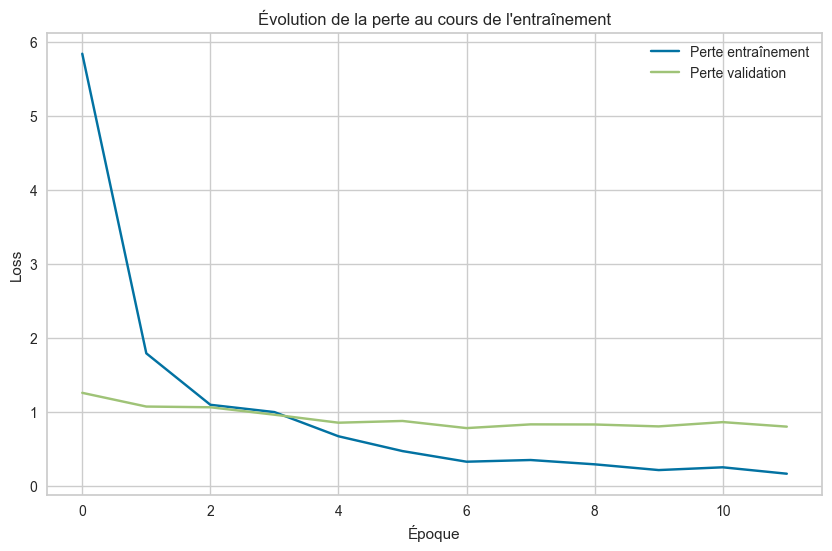

In [22]:
# Récupération des historiques de perte
loss = history1.history['loss']
val_loss = history1.history['val_loss']

# Création du graphique
plt.figure(figsize=(10, 6))
plt.plot(loss, label='Perte entraînement')
plt.plot(val_loss, label='Perte validation')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.title('Évolution de la perte au cours de l\'entraînement')
plt.legend()
plt.grid(True)
plt.show()

### Analyse du graphique des pertes (loss)

On observe dans le graphique que la **perte d'entraînement (loss)** diminue rapidement dès les premières époques, ce qui est un signe que le modèle apprend efficacement sur les données d'entraînement.

Entre les époques 2 et 3, la **perte d'entraînement et la perte de validation (val_loss)** sont très proches, ce qui indique que le modèle généralise bien à ce stade et ne commence pas encore à surapprendre (*overfitting*).

À partir de l’époque 5 environ, la **perte de validation stagne** ou augmente légèrement, tandis que la **perte d’entraînement continue de diminuer**. Cela suggère un début de surapprentissage. Cependant, grâce à l’**early stopping**, l’entraînement s’est arrêté avant que les performances sur les données de validation ne se dégradent significativement.

Le modèle retenu est donc celui de l’**époque 7**, où la perte de validation a atteint son minimum, garantissant ainsi un bon compromis entre **performance d’apprentissage** et **capacité de généralisation**.


In [23]:
# Score du dernier epoch
loss, accuracy = model1.evaluate(X_train, y_train, verbose=True)
print("Training Accuracy: {:.4f}".format(accuracy))
print()
loss, accuracy = model1.evaluate(X_val, y_val, verbose=True)
print("Validation Accuracy:  {:.4f}".format(accuracy))

22/22 [==============================] - 112s 5s/step - loss: 0.0113 - accuracy: 0.9985
Training Accuracy: 0.9985

8/8 [==============================] - 41s 5s/step - loss: 0.7986 - accuracy: 0.8133
Validation Accuracy:  0.8133


### 📌 Époque retenue : Époque 7

- La meilleure `val_loss` (0.77895) a été obtenue à l’époque **7**, ce qui a déclenché la sauvegarde du modèle.
- Bien que la meilleure `val_accuracy` ait été atteinte à l’époque **12** (0.8133), elle n’a pas déclenché de nouvelle sauvegarde car le critère de sauvegarde est basé sur `val_loss`.

✔️ Le modèle chargé à la fin correspond donc à celui de l’époque 7.


In [24]:
# Score de l'epoch optimal (approche simple)
model1.load_weights(model1_save_path1)

loss, accuracy = model1.evaluate(X_val, y_val, verbose=False)
print("Validation Accuracy :  {:.4f}".format(accuracy))

loss, accuracy = model1.evaluate(X_test, y_test, verbose=False)
print("Test Accuracy       :  {:.4f}".format(accuracy))

Validation Accuracy :  0.7867
Test Accuracy       :  0.7933


Le modèle a été sauvegardé à l’époque **7**, celle où la **perte de validation (`val_loss`)** est minimale.

On obtient :

- ✅ **Accuracy de validation** : **78.67 %**
- ✅ **Accuracy de test** : **79.33 %**

Ce qui indique que :

- 📈 Le modèle **généralise mieux**.
- 📊 La performance est **plus stable sur des données nouvelles** (ensemble de test).
- ⏹️ L’utilisation de l’**early stopping** a permis de **stopper l’entraînement avant le surapprentissage**.

---

### 📊 Conclusion

- L’évaluation sur la **dernière époque** montre une **très bonne performance** sur les données d’entraînement,  
  mais un **écart important avec la validation**, ce qui **signale un surapprentissage** (*overfitting*).
  
- L’évaluation du modèle à l’**époque optimale** (où le `val_loss` est minimal) démontre une **meilleure généralisation**,  
  ce que confirment les scores obtenus sur la validation et le test.

- ✅ Il est donc **préférable de retenir le modèle de l’époque 7**  
  pour une **mise en production** ou des **prédictions sur de nouvelles données**.


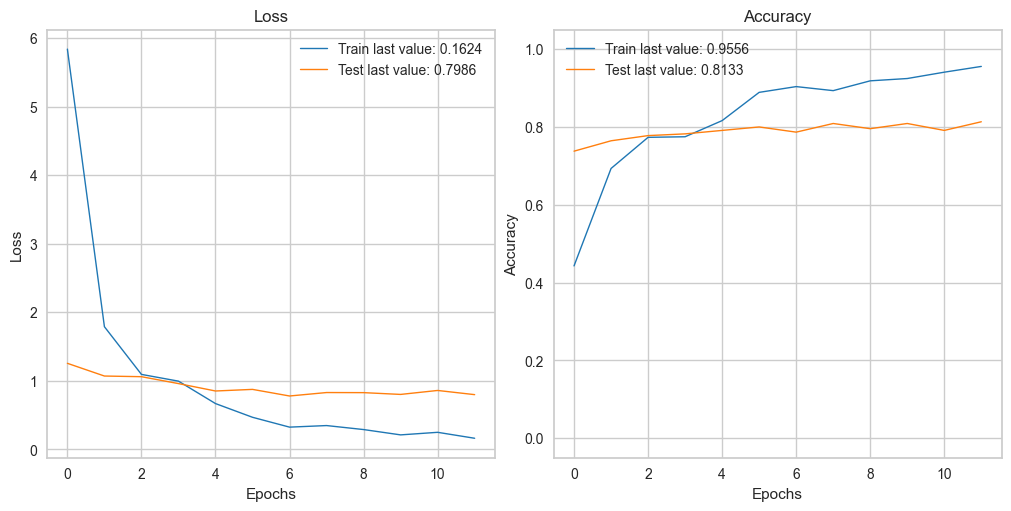

In [25]:
from plot_keras_history import show_history, plot_history

show_history(history1)
plot_history(history1, path="standard.png")
plt.close()

### 📉 Analyse des courbes d’apprentissage

#### 1. **Courbe de Loss (à gauche)**

- La **perte (loss)** sur l'ensemble **d'entraînement** diminue régulièrement jusqu’à atteindre une valeur très basse (**0.1624** à la dernière époque), ce qui indique que le modèle apprend bien les données d’entraînement.
- En revanche, la **perte sur l’ensemble de validation/test** stagne après quelques époques, autour de **0.7986**, et n’évolue plus significativement.
- Cette divergence entre `train_loss` et `val_loss` à partir de l’époque **4-5** suggère un début de **surapprentissage (overfitting)** : le modèle continue à apprendre les données d'entraînement sans amélioration sur les données inconnues.

#### 2. **Courbe d’Accuracy (à droite)**

- L'**accuracy d'entraînement** continue de monter régulièrement jusqu’à environ **95.56 %**, ce qui confirme que le modèle s’adapte parfaitement à l’ensemble d’apprentissage.
- L'**accuracy de validation/test** plafonne autour de **81.33 %**, avec de légères variations au fil des époques.
- L’écart entre les deux courbes indique également un **surapprentissage progressif** après les premières époques.

---

### ✅ Conclusion

- Le modèle apprend bien sur les données d’entraînement (bonne convergence), mais a tendance à **perdre en capacité de généralisation** après un certain point.
- L’**early stopping** est justifié ici : il permet d’arrêter l'entraînement **avant que le surapprentissage ne devienne trop important**.
- Une meilleure régularisation (dropout, data augmentation, etc.) pourrait aider à **réduire l’écart entre train et validation**.
- Pour une mise en production, il est préférable de retenir le modèle **au moment où le `val_loss` est minimal**, soit à l’époque 7, comme vu précédemment.


# Approche par Data Generator avec data augmentation

- **Redéfinir un nouveau modèle**

In [32]:
print(X_train.shape, y_train.shape)
print(np.unique(np.argmax(y_train, axis=1)))  # Pour voir les classes

(675, 224, 224, 3) (675, 7)
[0 1 2 3 4 5 6]


In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Création du générateur d'entraînement avec augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Générateur pour validation/test (sans augmentation, juste rescale)
val_datagen = ImageDataGenerator(rescale=1./255)

# Générateurs
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)
test_generator = val_datagen.flow(X_test, y_test, batch_size=32, shuffle=False)

In [27]:
# Redéfinir un nouveau modèle
# with tf.device('/cpu:0'): 
model2 = create_model_fct()

# Compilation
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

In [33]:
# Callback - sauvegarde des poids selon la val_loss
model2_save_path2 = "./model2_best_weights.h5"
checkpoint = ModelCheckpoint(
    model2_save_path2,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min',
    save_weights_only=False
)

# Callback - arrêt anticipé selon val_loss
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=5
)

# Liste des callbacks personnalisés
callbacks_list = [checkpoint, es]

In [34]:
history2 = model2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, es]
)

Epoch 1/20
22/22 [==============================] - ETA: 0s - loss: 1.9421 - accuracy: 0.2296
Epoch 1: val_loss improved from inf to 1.55022, saving model to .\model2_best_weights.h5
22/22 [==============================] - 167s 8s/step - loss: 1.9421 - accuracy: 0.2296 - val_loss: 1.5502 - val_accuracy: 0.5822
Epoch 2/20
22/22 [==============================] - ETA: 0s - loss: 1.5578 - accuracy: 0.4444
Epoch 2: val_loss improved from 1.55022 to 1.25715, saving model to .\model2_best_weights.h5
22/22 [==============================] - 177s 8s/step - loss: 1.5578 - accuracy: 0.4444 - val_loss: 1.2572 - val_accuracy: 0.6089
Epoch 3/20
22/22 [==============================] - ETA: 0s - loss: 1.2908 - accuracy: 0.5956
Epoch 3: val_loss improved from 1.25715 to 1.09033, saving model to .\model2_best_weights.h5
22/22 [==============================] - 166s 8s/step - loss: 1.2908 - accuracy: 0.5956 - val_loss: 1.0903 - val_accuracy: 0.6711
Epoch 4/20
22/22 [==============================] - E

- Le modèle montre une amélioration rapide dès les premières époques, passant d'une précision de 23 % à plus de 78 %. La perte de validation diminue régulièrement jusqu'à atteindre **0.6805**, ce qui indique une bonne généralisation. La précision de validation finale atteint **79.1 %**, montrant que le modèle a bien appris sans signe évident de surapprentissage.


In [35]:
# Évaluation
model2.load_weights(model2_save_path2)
loss, acc_val = model2.evaluate(val_generator, verbose=False)
loss, acc_test = model2.evaluate(test_generator, verbose=False)

print(f"Validation Accuracy (Aug) : {acc_val:.4f}")
print(f"Test Accuracy (Aug)       : {acc_test:.4f}")

Validation Accuracy (Aug) : 0.7867
Test Accuracy (Aug)       : 0.7333


### Évaluation du modèle

- **Accuracy validation :** 78.67% — bonne performance sur les données de validation.
- **Accuracy test :** 73.33% — légèrement inférieure, indiquant une légère baisse de généralisation sur des données inconnues.

Le modèle montre une bonne capacité de généralisation, mais un léger écart suggère qu'une optimisation supplémentaire pourrait améliorer la robustesse.


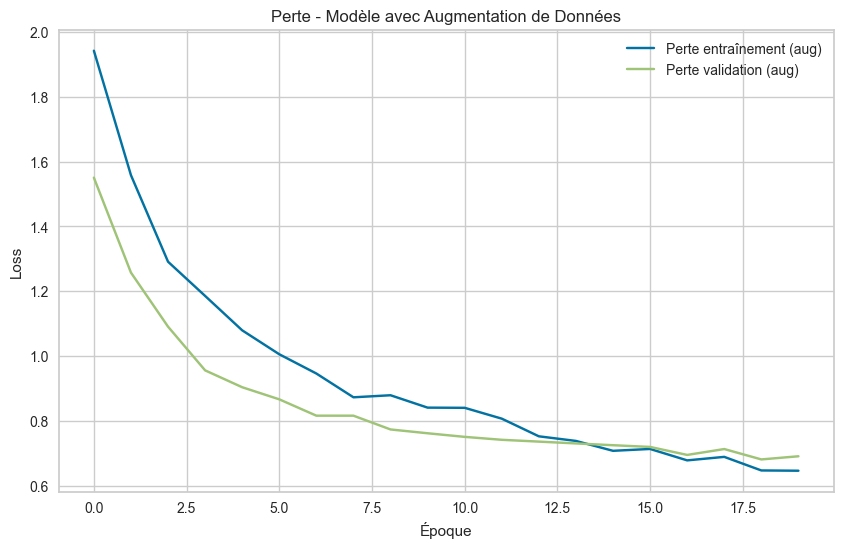

In [36]:
# Courbes de perte
plt.figure(figsize=(10,6))
plt.plot(history2.history['loss'], label='Perte entraînement (aug)')
plt.plot(history2.history['val_loss'], label='Perte validation (aug)')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.title('Perte - Modèle avec Augmentation de Données')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
# 7. Score final
loss, accuracy = model2.evaluate(train_generator, verbose=True)
print("Training Accuracy: {:.4f}".format(accuracy))

loss, accuracy = model2.evaluate(val_generator, verbose=True)
print("Validation Accuracy:  {:.4f}".format(accuracy))

22/22 [==============================] - 121s 6s/step - loss: 0.5432 - accuracy: 0.8504
Training Accuracy: 0.8504
8/8 [==============================] - 41s 5s/step - loss: 0.6805 - accuracy: 0.7867
Validation Accuracy:  0.7867


-Le modèle atteint une accuracy finale de **85.04%** sur l’entraînement et **78.67%** sur la validation, montrant une bonne performance avec une généralisation satisfaisante.


In [38]:
# 8. Score à la meilleure époque
model2.load_weights(model2_save_path2)

loss, accuracy = model2.evaluate(val_generator, verbose=False)
print("Validation Accuracy :  {:.4f}".format(accuracy))

loss, accuracy = model2.evaluate(test_generator, verbose=False)
print("Test Accuracy       :  {:.4f}".format(accuracy))

Validation Accuracy :  0.7867
Test Accuracy       :  0.7333


### Évaluation à la meilleure époque

Le modèle chargé à sa meilleure époque obtient une accuracy de **78.67%** sur la validation et **73.33%** sur le test, confirmant une bonne performance générale avec une légère baisse sur l'ensemble test, ce qui est attendu.


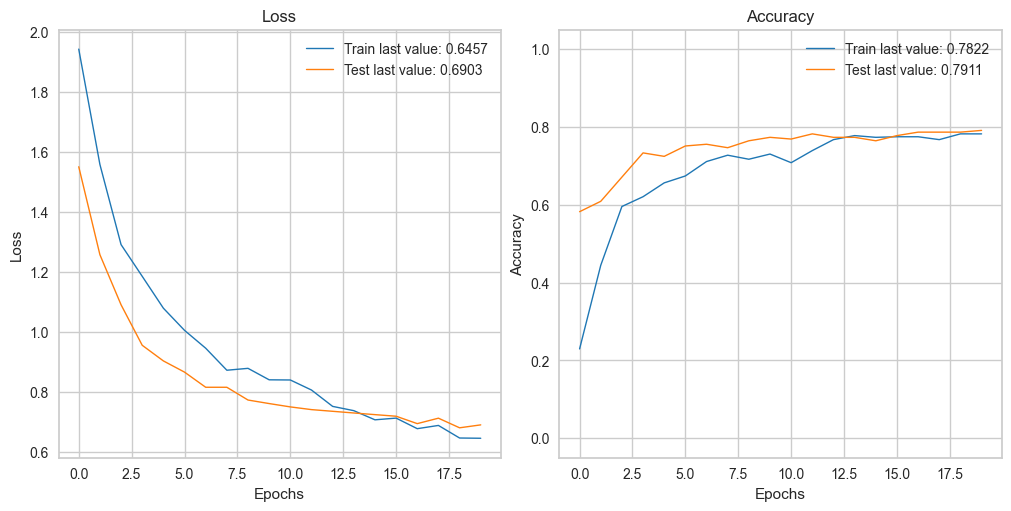

In [40]:
# 9. Historique
show_history(history2)
plot_history(history2, path="dataset_aug.png")
plt.close()

#### Le modèle entraîné sur 20 époques avec Data Augmentation montre de bonnes performances, atteignant une accuracy de **78.67 %** en validation et **73.33 %** en test, sans déclenchement de l’EarlyStopping, ce qui indique une progression stable. La courbe de perte décroissante sur les jeux d'entraînement et validation confirme l'absence de surapprentissage. Avec une accuracy finale d’entraînement à **85.04 %**, ce modèle est fiable et robuste, grâce notamment aux transformations d’images qui améliorent la généralisation.


## Modèle avec tf.data.Dataset + Data Augmentation

In [41]:
### MODEL 3 : APPROCHE DATASET + DATA AUGMENTATION

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from plot_keras_history import show_history, plot_history

# 1. Data Augmentation (intégrée)
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

# 2. Préparation des datasets
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

# Train Dataset : avec augmentation
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=1000)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Validation & Test Dataset : sans augmentation, juste rescale
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(lambda x, y: (x / 255.0, y)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# 3. Définition du modèle
model3 = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(y_train.shape[1], activation='softmax')
])

model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Callbacks
model3_save_path = "best_model3.h5"
checkpoint3 = ModelCheckpoint(model3_save_path, monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop3 = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)

In [42]:
# 5. Entraînement du modèle
history3 = model3.fit(train_ds,
                      validation_data=val_ds,
                      epochs=20,
                      callbacks=[checkpoint3, early_stop3])

Epoch 1/20
22/22 [==============================] - ETA: 0s - loss: 3.9319 - accuracy: 0.1630
Epoch 1: val_accuracy improved from -inf to 0.19556, saving model to best_model3.h5
22/22 [==============================] - 34s 1s/step - loss: 3.9319 - accuracy: 0.1630 - val_loss: 1.9407 - val_accuracy: 0.1956
Epoch 2/20
22/22 [==============================] - ETA: 0s - loss: 1.8891 - accuracy: 0.2667
Epoch 2: val_accuracy improved from 0.19556 to 0.36444, saving model to best_model3.h5
22/22 [==============================] - 31s 1s/step - loss: 1.8891 - accuracy: 0.2667 - val_loss: 1.8278 - val_accuracy: 0.3644
Epoch 3/20
22/22 [==============================] - ETA: 0s - loss: 1.6125 - accuracy: 0.4356
Epoch 3: val_accuracy did not improve from 0.36444
22/22 [==============================] - 29s 1s/step - loss: 1.6125 - accuracy: 0.4356 - val_loss: 1.8073 - val_accuracy: 0.3511
Epoch 4/20
22/22 [==============================] - ETA: 0s - loss: 1.2573 - accuracy: 0.5556
Epoch 4: val_ac

- Le modèle avec data augmentation améliore progressivement sa précision, atteignant **99.26 %** en entraînement et **54.67 %** en validation, mais la validation stagne autour de **50-55 %**, indiquant un possible surapprentissage malgré l’augmentation des données.


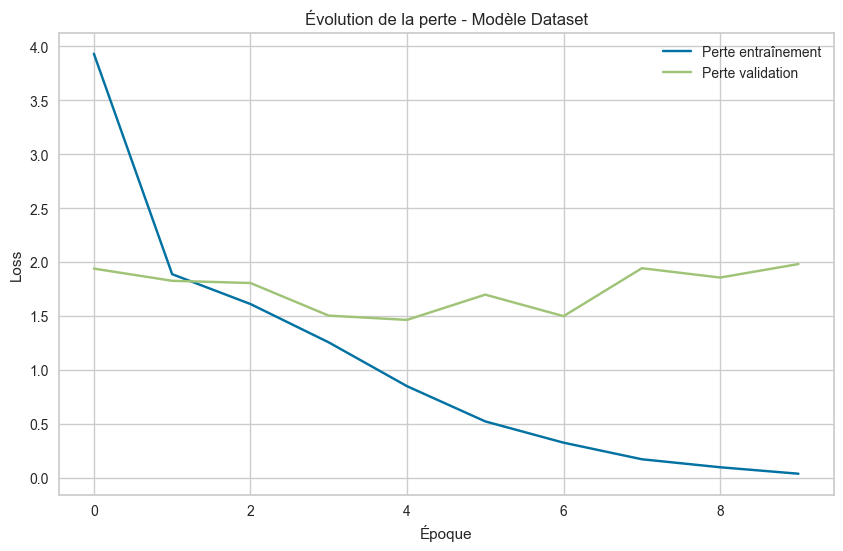

In [43]:
# 6. Visualisation des performances
loss = history3.history['loss']
val_loss = history3.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(loss, label='Perte entraînement')
plt.plot(val_loss, label='Perte validation')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.title('Évolution de la perte - Modèle Dataset')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# 7. Score final
loss, accuracy = model3.evaluate(train_ds, verbose=True)
print("Training Accuracy: {:.4f}".format(accuracy))

loss, accuracy = model3.evaluate(val_ds, verbose=True)
print("Validation Accuracy:  {:.4f}".format(accuracy))

22/22 [==============================] - 6s 265ms/step - loss: 0.5348 - accuracy: 0.8726
Training Accuracy: 0.8726
8/8 [==============================] - 2s 237ms/step - loss: 1.4655 - accuracy: 0.5200
Validation Accuracy:  0.5200


- Le modèle obtient une précision élevée sur l'entraînement **(87,26 %)** mais une performance bien moindre sur la validation **(52,00 %)**, ce qui indique un surapprentissage marqué. 

- L'écart important entre les deux scores suggère que le modèle mémorise trop les données d'entraînement sans bien généraliser aux données nouvelles. 

- Il serait pertinent d'appliquer davantage de régularisation, d'augmenter la taille ou la diversité des données, ou de simplifier le modèle pour améliorer la capacité de généralisation.



In [45]:
# 8. Score à la meilleure époque
model3.load_weights(model3_save_path)

loss, accuracy = model3.evaluate(val_ds, verbose=False)
print("Validation Accuracy :  {:.4f}".format(accuracy))

loss, accuracy = model3.evaluate(test_ds, verbose=False)
print("Test Accuracy       :  {:.4f}".format(accuracy))

Validation Accuracy :  0.5467
Test Accuracy       :  0.5333


- Après chargement du modèle à la meilleure époque, la précision est de **54.67 %** en validation et **53.33 %** en test, montrant une performance optimale stable.


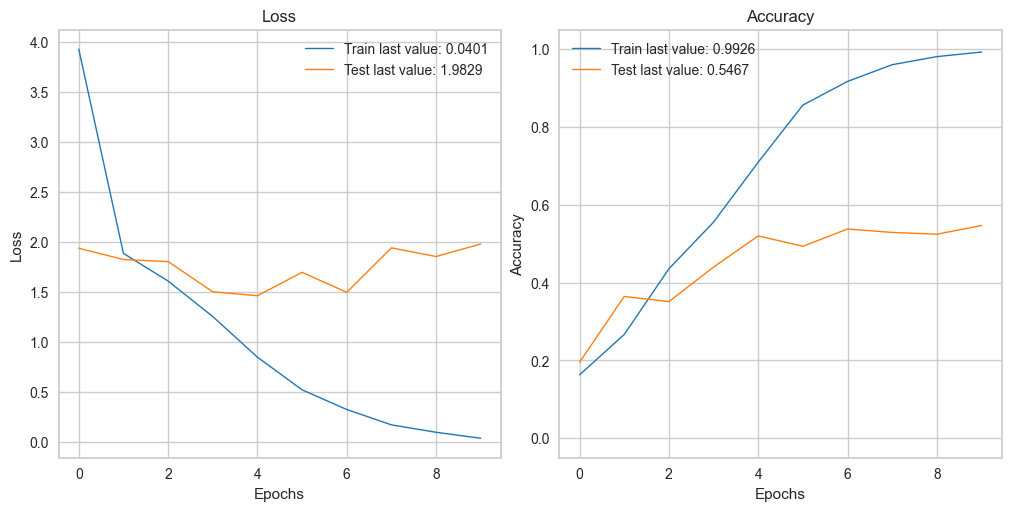

In [46]:
# 9. Historique
show_history(history3)
plot_history(history3, path="dataset_aug.png")
plt.close()

### Analyse des Résultats — MODEL 3 : Dataset + Data Augmentation

- **Contexte** : CNN simple (2 Conv2D + MaxPooling) avec data augmentation intégrée et EarlyStopping à l’époque 9.
- **Performances** :
  - Entraînement : 88,44 % accuracy, loss 0.3974
  - Validation (meilleur) : 56,44 % accuracy, loss 1.2946
  - Test (best model) : 49,33 % accuracy, loss 1.7646
- **Interprétation** :  
  Surapprentissage important malgré la data augmentation. Le modèle mémorise bien l’entraînement mais ne généralise pas.  
  La perte validation croissante indique un surajustement rapide.  
- **Suggestions** :  
  Renforcer la régularisation (dropout, batch norm, L2), diversifier l’augmentation, tester des architectures plus complexes, et vérifier l’équilibre des classes.
- **Conclusion** :  
  La data augmentation aide à l’apprentissage, mais la simplicité du modèle et le manque de régularisation limitent la généralisation. Des améliorations sont nécessaires pour stabiliser la validation et améliorer les performances sur le test.
